# BDIS — Full Pipeline (Realistic Industry Data)


## Install

In [1]:
!pip install pandas numpy scikit-learn xgboost lightgbm shap lifelines matplotlib -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.4 MB/s eta 0:00:00


## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import shap

np.random.seed(42)

FEATURE_COLS = [
    'engagement_frequency',
    'response_latency_hrs',
    'inactivity_gap_days',
    'behavioral_decay',
    'session_duration_min',
    'missed_checkins',
    'days_since_last_login',
    'message_open_rate',
]

## Step 1 — Load Data

In [39]:
df = pd.read_csv('patient_data (2).csv')




In [40]:
print(df.shape)
print(f"Churn rate: {df['churn_label'].mean():.2%}")

(600, 13)
Churn rate: 26.67%


In [41]:
df.head(5)

,patient_id,engagement_frequency,response_latency_hrs,inactivity_gap_days,behavioral_decay,session_duration_min,missed_checkins,days_since_last_login,message_open_rate,true_group,churn_label,risk_tier,_risk_signal
0,PT-1000,3.33,17.46,13,0.074,12,3,5,0.465,1,0,Medium,0.1593
1,PT-1001,0.38,35.97,28,-0.537,3,8,23,0.050,2,0,High,0.5432
2,PT-1002,0.52,43.74,33,-0.483,7,3,19,0.225,2,1,High,0.4853
3,PT-1003,0.48,16.56,31,-0.308,2,7,24,0.238,2,1,High,0.4388
4,PT-1004,3.53,4.73,6,0.097,24,1,4,0.585,0,0,Low,0.1035


In [42]:
# Verify data types
print("Data types:")
print(df[FEATURE_COLS].dtypes)

Data types:
engagement_frequency     float64
response_latency_hrs     float64
inactivity_gap_days        int64
behavioral_decay         float64
session_duration_min       int64
missed_checkins            int64
days_since_last_login      int64
message_open_rate        float64
dtype: object


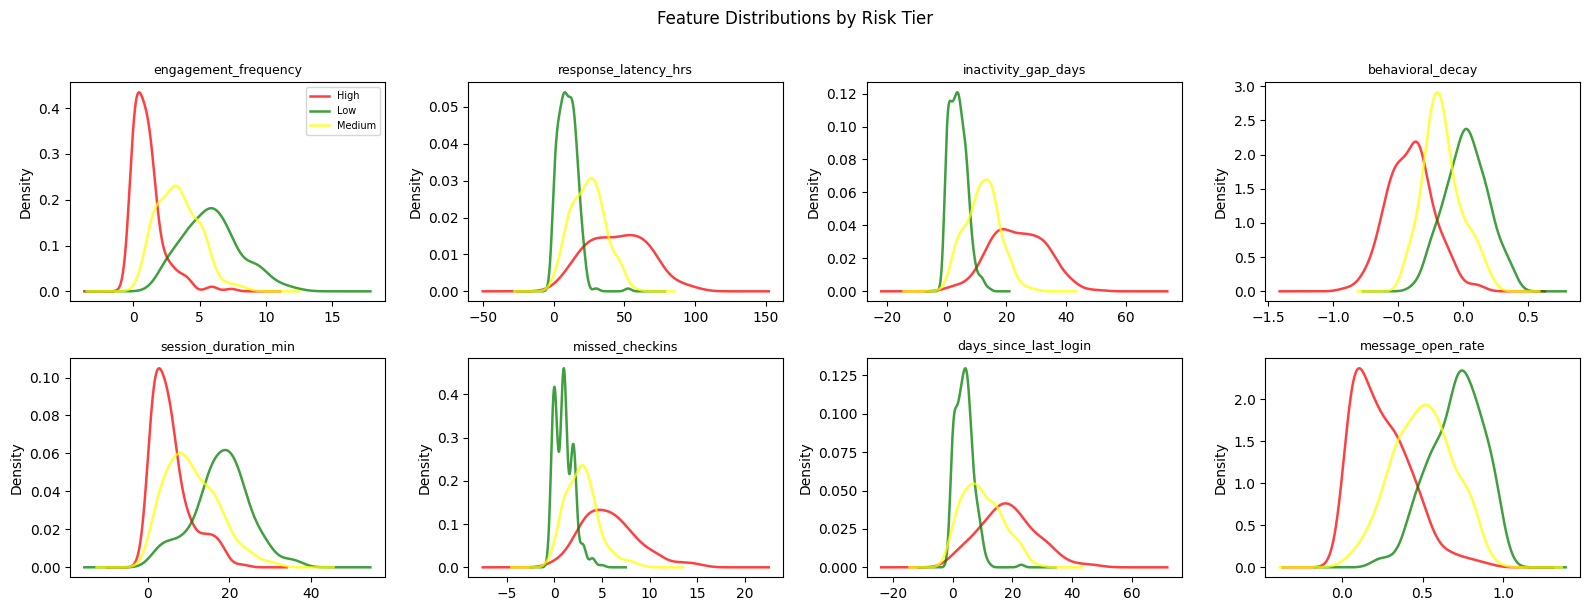

In [43]:
# Feature distributions by risk tier
tier_colors = {'High':'Red','Medium':'Yellow','Low':'Green'}
fig, axes = plt.subplots(2, 4, figsize=(16,6))
axes = axes.flatten()
for i, feat in enumerate(FEATURE_COLS):
    for tier, grp in df.groupby('risk_tier'):
        grp[feat].plot(kind='kde', ax=axes[i], label=tier,
                       color=tier_colors[tier], alpha=0.75, linewidth=1.8)
    axes[i].set_title(feat, fontsize=9)
    if i==0: axes[i].legend(fontsize=7)
plt.suptitle('Feature Distributions by Risk Tier', y=1.01)
plt.tight_layout()
plt.show()

## Step 2 — Train / Test Split

In [8]:
X = df[FEATURE_COLS]
y = df['churn_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train churn rate: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Train: 480 | Test: 120
Train churn rate: 26.67% | Test: 26.67%


## Step 3 — Model Comparison
Compare 5 models. Best model is selected automatically by CV AUC.

In [9]:
candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                       learning_rate=0.05, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05,
                                         eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM':            LGBMClassifier(n_estimators=150, max_depth=4, learning_rate=0.05,
                                          random_state=42, verbose=-1),
}

results = []
fitted_models = {}

for name, m in candidate_models.items():
    m.fit(X_train, y_train)
    fitted_models[name] = m
    test_auc = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
    cv_auc   = cross_val_score(m, X, y, cv=5, scoring='roc_auc').mean()
    results.append({'Model': name, 'Test AUC': round(test_auc,4), 'CV AUC (5-fold)': round(cv_auc,4)})
    print(f"{name}:")
    print(classification_report(y_test, m.predict(X_test), digits=3))
    print("-"*40)

results_df = pd.DataFrame(results).sort_values('CV AUC (5-fold)', ascending=False)
print("\n=== Model Leaderboard (ranked by CV AUC) ===")
print(results_df.to_string(index=False))

Logistic Regression:
              precision    recall  f1-score   support

           0      0.842     0.966     0.899        88
           1      0.842     0.500     0.627        32

    accuracy                          0.842       120
   macro avg      0.842     0.733     0.763       120
weighted avg      0.842     0.842     0.827       120

----------------------------------------
Random Forest:
              precision    recall  f1-score   support

           0      0.851     0.977     0.910        88
           1      0.895     0.531     0.667        32

    accuracy                          0.858       120
   macro avg      0.873     0.754     0.788       120
weighted avg      0.863     0.858     0.845       120

----------------------------------------
Gradient Boosting:
              precision    recall  f1-score   support

           0      0.842     0.966     0.899        88
           1      0.842     0.500     0.627        32

    accuracy                          0.842  

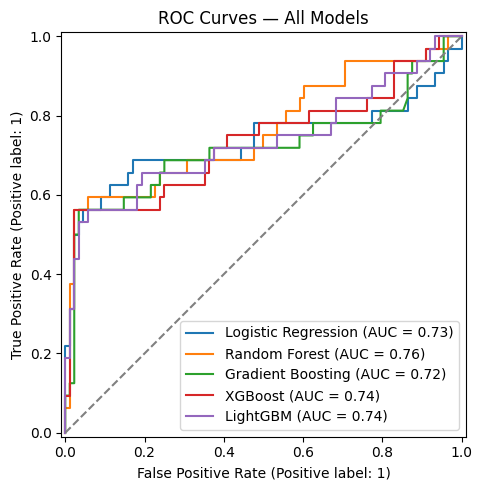

In [10]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, m in fitted_models.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1],'--',color='gray',label='Random baseline')
ax.set_title('ROC Curves — All Models')
plt.tight_layout()
plt.show()

In [11]:
# Auto-select best model by CV AUC
best_name  = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
best_cv    = results_df.iloc[0]['CV AUC (5-fold)']
best_test  = results_df.iloc[0]['Test AUC']

print(f"Selected model : {best_name}")
print(f"CV AUC         : {best_cv}")
print(f"Test AUC       : {best_test}")
print(f"\nReason: Highest cross-validated AUC across 5 folds.")
print("CV AUC is preferred over test AUC — more robust, less sensitive to one split.")

Selected model : Random Forest
CV AUC         : 0.8129
Test AUC       : 0.7617

Reason: Highest cross-validated AUC across 5 folds.
CV AUC is preferred over test AUC — more robust, less sensitive to one split.


In [12]:
# Full cohort risk scores using best model
df['risk_score'] = best_model.predict_proba(X)[:, 1]
print(f"Score range: {df['risk_score'].min():.3f} — {df['risk_score'].max():.3f}")

# Risk tiers already in data from generation step
print("\nRisk tier distribution:")
print(df['risk_tier'].value_counts())

Score range: 0.028 — 0.999

Risk tier distribution:
risk_tier
Low       240
Medium    180
High      180
Name: count, dtype: int64


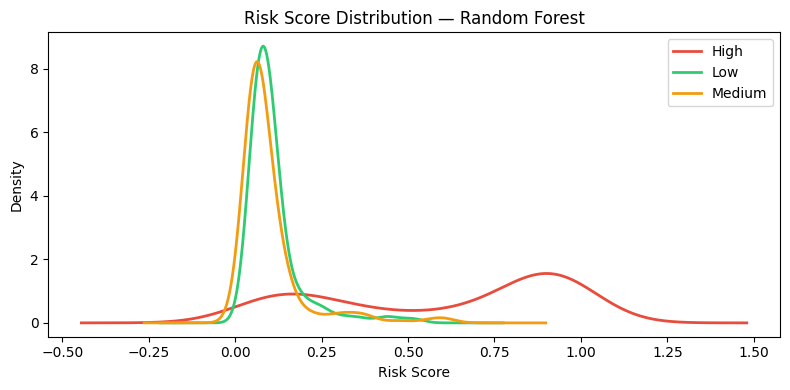

In [13]:
# Score distribution by tier
fig, ax = plt.subplots(figsize=(8, 4))
for tier, grp in df.groupby('risk_tier'):
    grp['risk_score'].plot(kind='kde', ax=ax, label=tier, color=tier_colors[tier], linewidth=2)
ax.set_title(f'Risk Score Distribution — {best_name}')
ax.set_xlabel('Risk Score')
ax.legend()
plt.tight_layout()
plt.show()

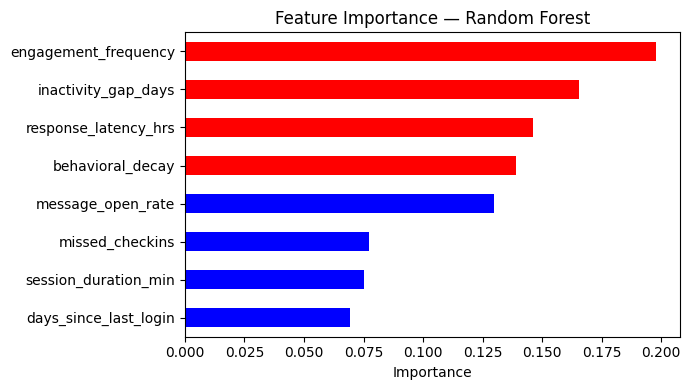

In [45]:
# Feature importance (if tree model)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
    fig, ax = plt.subplots(figsize=(7, 4))
    fi.plot(kind='barh', ax=ax,
            color=['Red' if v > fi.median() else 'Blue' for v in fi.values])
    ax.set_title(f'Feature Importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not have feature_importances_ — use SHAP for explanation.")

## Step 4 — Survival Analysis

In [15]:
# Build survival data
# Real data: duration = last_active_date - enrollment_date
#            event_observed = 1 if confirmed dropout, 0 if still active (censored)
scores_arr = df['risk_score'].values
scale = 90 * (1 - scores_arr) + 5
df['duration_days']  = np.random.exponential(scale=scale).clip(1, 180).astype(int)
df['event_observed'] = (np.random.rand(len(df)) < (0.3 + 0.6*scores_arr)).astype(int)
print(f"Events: {df['event_observed'].sum()} / {len(df)} ({df['event_observed'].mean():.1%})")
print(f"Median duration: {df['duration_days'].median():.0f} days")

Events: 270 / 600 (45.0%)
Median duration: 41 days


High     — median survival: 21 days | n=180
Medium   — median survival: 151 days | n=180
Low      — median survival: 179 days | n=240


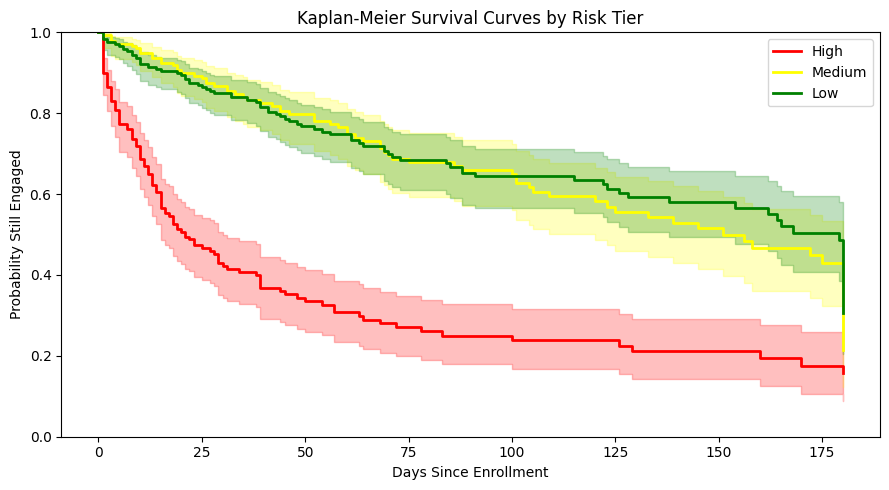

In [49]:
# KM curves by risk tier
# Re-create duration_days and event_observed if they are missing due to a DataFrame reset.
# Also re-create risk_score if it's missing.
if 'risk_score' not in df.columns:
    df['risk_score'] = best_model.predict_proba(X)[:, 1]

scores_arr = df['risk_score'].values
scale = 90 * (1 - scores_arr) + 5
df['duration_days']  = np.random.exponential(scale=scale).clip(1, 180).astype(int)
df['event_observed'] = (np.random.rand(len(df)) < (0.3 + 0.6*scores_arr)).astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
for tier in ['High','Medium','Low']:
    subset = df[df['risk_tier']==tier]
    kmf = KaplanMeierFitter()
    kmf.fit(subset['duration_days'], event_observed=subset['event_observed'], label=tier)
    kmf.plot_survival_function(ax=ax, color=tier_colors[tier], ci_show=True, linewidth=2)
    print(f"{tier:8s} — median survival: {kmf.median_survival_time_:.0f} days | n={len(subset)}")
ax.set_title('Kaplan-Meier Survival Curves by Risk Tier')
ax.set_xlabel('Days Since Enrollment')
ax.set_ylabel('Probability Still Engaged')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [50]:
# Log-rank test
high_g = df[df['risk_tier']=='High']
low_g  = df[df['risk_tier']=='Low']
result = logrank_test(high_g['duration_days'], low_g['duration_days'],
                      event_observed_A=high_g['event_observed'],
                      event_observed_B=low_g['event_observed'])
print(f"Log-rank p-value (High vs Low): {result.p_value:.6f}")
print('Statistically significant' if result.p_value < 0.05 else 'Not significant')

Log-rank p-value (High vs Low): 0.000000
Statistically significant


H₀ (null hypothesis): The survival curves of High-risk and Low-risk patients are the same — no difference in dropout timing.
H₁ (alternative): The curves are different. one group drops out significantly faster.
p-value < 0.05 → reject H₀ → curves are statistically different .  Risk tiers actually separate patients by dropout timing.

In [51]:
# Cox PH
cox_features = ['engagement_frequency','response_latency_hrs','inactivity_gap_days',
                'behavioral_decay','missed_checkins','message_open_rate']
cox_df = df[cox_features+['duration_days','event_observed']].copy()
sc = StandardScaler()
cox_df[cox_features] = sc.fit_transform(cox_df[cox_features])
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration_days', event_col='event_observed')
print(f"Concordance Index: {cph.concordance_index_:.4f}")
cph.print_summary()

Concordance Index: 0.7105


<lifelines.CoxPHFitter: fitted with 600 total observations, 318 right-censored observations>
             duration col = 'duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 600
number of events observed = 282
   partial log-likelihood = -1517.11
         time fit was run = 2026-05-18 18:04:36 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
engagement_frequency  0.03      1.03      0.09           -0.14            0.20                0.87                1.22
response_latency_hrs  0.31      1.37      0.08            0.16            0.47                1.17                1.60
inactivity_gap_days   0.09      1.09      0.10           -0.10            0.28                0.90                1.33
behavioral_decay     -0.17      0.85      0.09           -0.34            0.01                0.71                1.01
missed_checkins       0.11      1.12      0.07           -0.03            0.26                0.97                1.29
message_open_rate    -0.26      0.77      0.09           -0.44           -0.08                0.64                0.92

                      cmp to     z      p  -log2(p)
covariate                                          
engagement_frequency    0.00  0.31   0.76      0.40
response_latency_hrs    0.00  3.88 <0.005     13.24
inactivity_gap_days     0.00  0.91   0.36      1.46
behavioral_decay        0.00 -1.88   0.06      4.04
missed_checkins         0.00  1.56   0.12      3.07
message_open_rate       0.00 -2.90 <0.005      8.05
---
Concordance = 0.71
Partial AIC = 3046.22
log-likelihood ratio test = 141.86 on 6 df
-log2(p) of ll-ratio test = 90.99

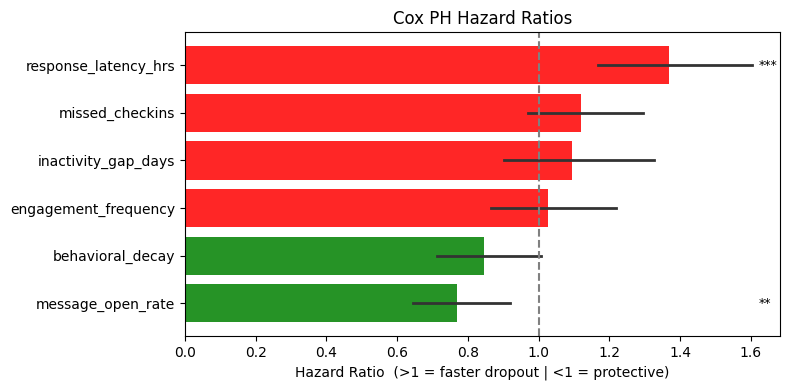

* p<0.05  ** p<0.01  *** p<0.001


In [53]:
# Hazard ratio plot
summary = cph.summary[['exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']].sort_values('exp(coef)')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(summary.index, summary['exp(coef)'],
        color=['red' if v>1 else 'green' for v in summary['exp(coef)']], alpha=0.85)
for i,(idx,row) in enumerate(summary.iterrows()):
    ax.plot([row['exp(coef) lower 95%'],row['exp(coef) upper 95%']],[i,i],color='#333',lw=2)
ax.axvline(1.0, color='gray', linestyle='--')
ax.set_xlabel('Hazard Ratio  (>1 = faster dropout | <1 = protective)')
ax.set_title('Cox PH Hazard Ratios')
for i,(idx,row) in enumerate(summary.iterrows()):
    sig='***' if row['p']<0.001 else ('**' if row['p']<0.01 else ('*' if row['p']<0.05 else ''))
    if sig: ax.text(summary['exp(coef) upper 95%'].max()+0.02,i,sig,va='center',fontsize=9)
plt.tight_layout()
plt.show()
print("* p<0.05  ** p<0.01  *** p<0.001")

## Step 5 — SHAP Explainability

In [54]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)
if isinstance(shap_values, list): shap_values = shap_values[1]
print(f"SHAP shape: {shap_values.shape}")

SHAP shape: (600, 8, 2)


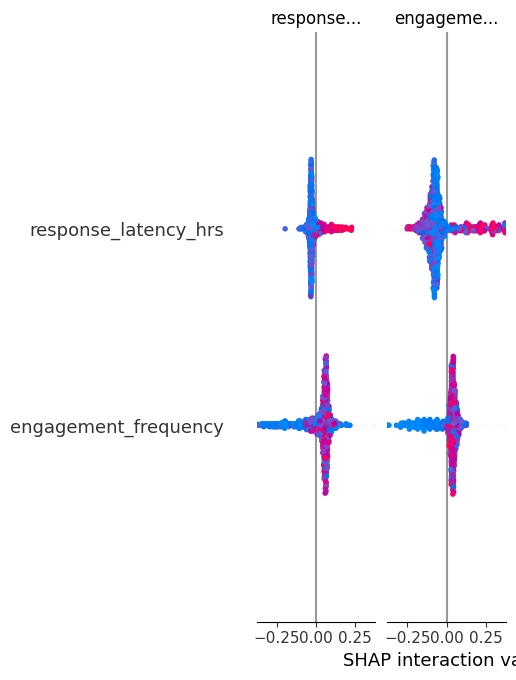

In [55]:
shap.summary_plot(shap_values, X, plot_type='bar', show=True)

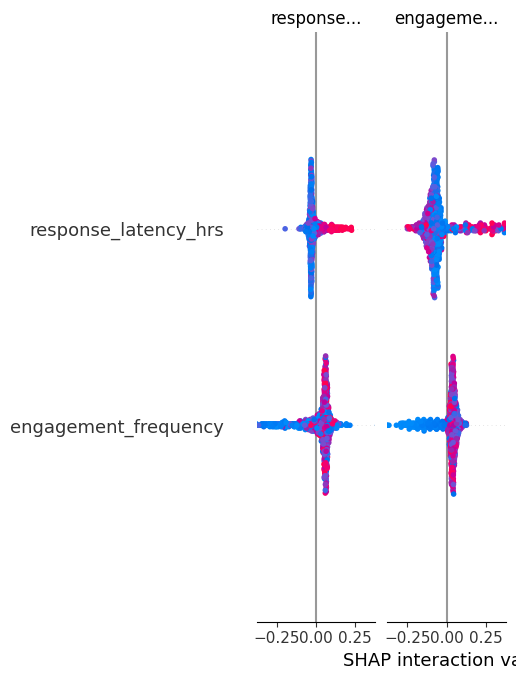

In [22]:
shap.summary_plot(shap_values, X, show=True)

Patient: PT-1297 | Score: 0.9986 | Tier: High


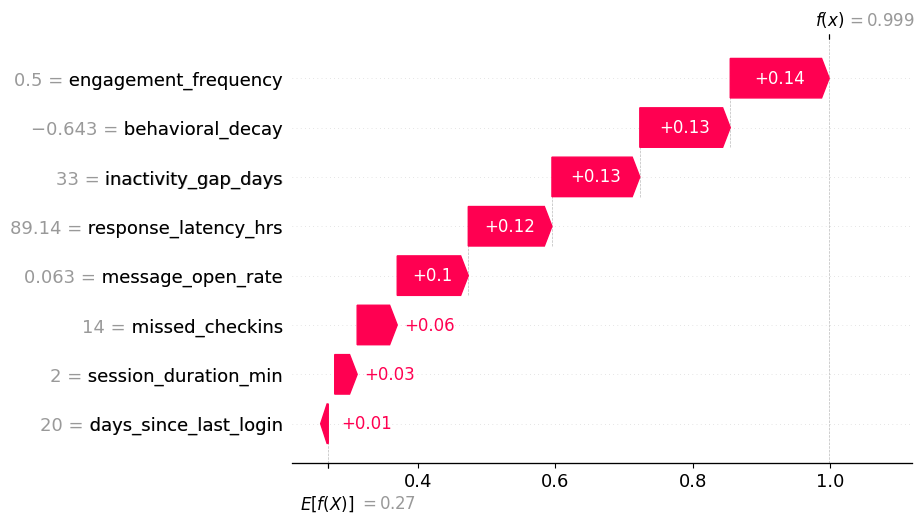

In [24]:
top_idx = df['risk_score'].idxmax()
print(f"Patient: {df.loc[top_idx,'patient_id']} | Score: {df.loc[top_idx,'risk_score']:.4f} | Tier: {df.loc[top_idx,'risk_tier']}")
shap.waterfall_plot(shap.Explanation(
    values=shap_values[top_idx, :, 1], # Select SHAP values for class 1 for the top_idx patient
    base_values=explainer.expected_value[1], # Select expected value for class 1
    data=X.iloc[top_idx].values,
    feature_names=FEATURE_COLS
))

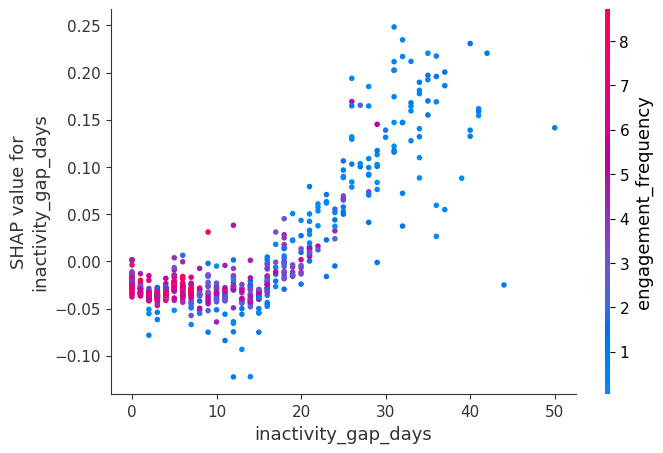

In [26]:
shap.dependence_plot('inactivity_gap_days', shap_values[:, :, 1], X, show=True)

In [56]:
# Top driver per patient
df['top_driver'] = [
    FEATURE_COLS[np.argmax(np.abs(shap_values[i, :, 1]))] for i in range(len(df))
]
print("Most common top SHAP drivers:")
print(df['top_driver'].value_counts())

Most common top SHAP drivers:
top_driver
engagement_frequency     269
message_open_rate        109
behavioral_decay          70
inactivity_gap_days       68
response_latency_hrs      48
missed_checkins           17
session_duration_min      15
days_since_last_login      4
Name: count, dtype: int64


## Step 6 — Behavioral Segmentation

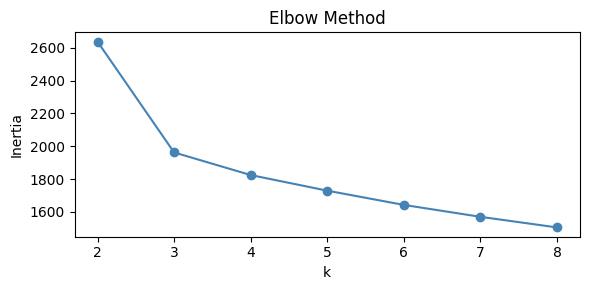

In [57]:
# Elbow method
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(2,9), inertias, marker='o', color='steelblue')
ax.set_xlabel('k'); ax.set_ylabel('Inertia')
ax.set_title('Elbow Method')
plt.tight_layout()
plt.show()

In [58]:
# KMeans k=4
km     = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# rank clusters by composite risk proxy → assign archetype names
cluster_risk = []
for c in range(4):
    mask = labels==c
    avg  = ((1/(df.loc[mask,'engagement_frequency'].mean()+0.5))*0.3 +
             (df.loc[mask,'inactivity_gap_days'].mean()/60)*0.3 +
             (df.loc[mask,'missed_checkins'].mean()/15)*0.4)
    cluster_risk.append((c, avg))
sc_order = [c for c,_ in sorted(cluster_risk, key=lambda x:x[1])]
archetype_map = {sc_order[0]:'Stable', sc_order[1]:'Decaying',
                 sc_order[2]:'Erratic', sc_order[3]:'High-Risk Inactive'}
df['segment'] = [archetype_map[c] for c in labels]
print("Segment distribution:")
print(df['segment'].value_counts())
print("\nVerify — cluster means (use this to confirm label assignments make sense):")
print(df.groupby('segment')[['engagement_frequency','inactivity_gap_days','missed_checkins','behavioral_decay']].mean().round(2))

Segment distribution:
segment
Stable      251
Decaying    220
Erratic     129
Name: count, dtype: int64

Verify — cluster means (use this to confirm label assignments make sense):
          engagement_frequency  inactivity_gap_days  missed_checkins  \
segment                                                                
Decaying                  3.10                13.33             3.15   
Erratic                   0.76                27.37             6.69   
Stable                    5.79                 3.63             1.08   

          behavioral_decay  
segment                     
Decaying             -0.19  
Erratic              -0.45  
Stable                0.02  


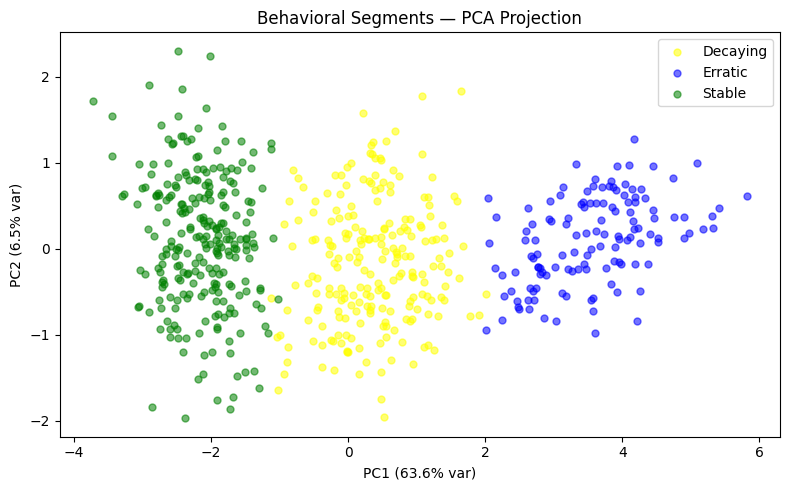

In [63]:
# PCA visualization
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df['PC1'] = coords[:,0]; df['PC2'] = coords[:,1]

seg_colors = {'Stable':'green','Decaying':'yellow','Erratic':'blue'}
fig, ax = plt.subplots(figsize=(8, 5))
for seg, grp in df.groupby('segment'):
    ax.scatter(grp['PC1'], grp['PC2'], label=seg, alpha=0.55, s=25, color=seg_colors[seg])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title('Behavioral Segments — PCA Projection')
ax.legend(); plt.tight_layout(); plt.show()

In [60]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"k={k}  silhouette={sil:.4f}")

k=2  silhouette=0.3834
k=3  silhouette=0.2971
k=4  silhouette=0.2151
k=5  silhouette=0.1648
k=6  silhouette=0.1442


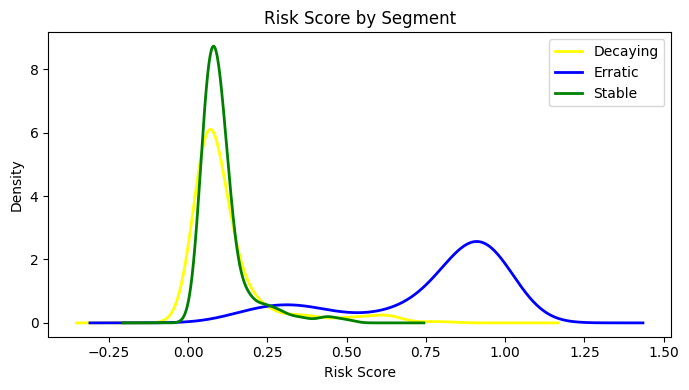

In [64]:
# Risk score by segment
fig, ax = plt.subplots(figsize=(7, 4))
for seg, grp in df.groupby('segment'):
    grp['risk_score'].plot(kind='kde', ax=ax, label=seg, color=seg_colors[seg], linewidth=2)
ax.set_title('Risk Score by Segment')
ax.set_xlabel('Risk Score')
ax.legend(); plt.tight_layout(); plt.show()

## Step 7 — Intervention Engine

In [65]:
def get_action(row):
    seg, tier, decay = row['segment'], row['risk_tier'], row['behavioral_decay']

    if seg == 'Erratic':
        return 'Human Outreach', 'Erratic patients unpredictable — proactive contact'
    if seg == 'Decaying' and decay < -0.35:
        return 'Human Outreach', f'Steep decay ({decay:.2f}) — escalate'
    if seg == 'Decaying':
        return 'Automated Nudge', 'Gradual decline — re-engagement message'
    if tier == 'High':
        return 'Human Outreach', 'Risk threshold exceeded'
    if tier == 'Medium':
        return 'Automated Nudge', 'Risk threshold — monitor closely'
    return 'No Action', 'Stable — passive monitoring'

res = df.apply(get_action, axis=1, result_type='expand')
df['action'] = res[0]; df['action_reason'] = res[1]
print(df['action'].value_counts())
print("\nActions by segment:")
print(pd.crosstab(df['segment'], df['action']))

action
No Action          231
Automated Nudge    206
Human Outreach     163
Name: count, dtype: int64

Actions by segment:
action    Automated Nudge  Human Outreach  No Action
segment                                             
Decaying              189              31          0
Erratic                 0             129          0
Stable                 17               3        231


In [66]:
# Clinician worklist
worklist = df[df['action']=='Human Outreach'][[
    'patient_id','risk_score','risk_tier','segment','action_reason','top_driver',
    'inactivity_gap_days','missed_checkins','days_since_last_login'
]].sort_values('risk_score', ascending=False).reset_index(drop=True)
print(f"Human outreach required: {len(worklist)} patients")
worklist.head(15)

Human outreach required: 163 patients


,patient_id,risk_score,risk_tier,segment,action_reason,top_driver,inactivity_gap_days,missed_checkins,days_since_last_login
0,PT-1297,0.998565,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,33,14,20
1,PT-1172,0.995232,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,30,6,19
2,PT-1460,0.986232,High,Erratic,Erratic patients unpredictable — proactive con...,behavioral_decay,21,8,16
3,PT-1233,0.979278,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,16,7,15
4,PT-1222,0.977399,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,25,8,15
5,PT-1048,0.976992,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,22,3,11
6,PT-1120,0.975375,High,Erratic,Erratic patients unpredictable — proactive con...,inactivity_gap_days,34,6,23
7,PT-1114,0.975232,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,23,14,16
8,PT-1096,0.971799,High,Erratic,Erratic patients unpredictable — proactive con...,behavioral_decay,16,8,37
9,PT-1287,0.971588,High,Erratic,Erratic patients unpredictable — proactive con...,engagement_frequency,26,4,31


In [67]:
# Automated nudge queue
nudge_queue = df[df['action']=='Automated Nudge'][[
    'patient_id','risk_score','segment','action_reason',
    'top_driver','days_since_last_login','message_open_rate'
]].sort_values('risk_score', ascending=False).reset_index(drop=True)
print(f"Automated nudge queue: {len(nudge_queue)} patients")
nudge_queue.head(10)

Automated nudge queue: 206 patients


,patient_id,risk_score,segment,action_reason,top_driver,days_since_last_login,message_open_rate
0,PT-1288,0.655357,Decaying,Gradual decline — re-engagement message,engagement_frequency,15,0.254
1,PT-1162,0.641011,Decaying,Gradual decline — re-engagement message,engagement_frequency,17,0.414
2,PT-1421,0.631844,Decaying,Gradual decline — re-engagement message,engagement_frequency,3,0.490
3,PT-1546,0.618472,Decaying,Gradual decline — re-engagement message,engagement_frequency,4,0.492
4,PT-1031,0.607985,Decaying,Gradual decline — re-engagement message,message_open_rate,21,0.184
5,PT-1342,0.598205,Decaying,Gradual decline — re-engagement message,session_duration_min,22,0.686
6,PT-1005,0.557883,Decaying,Gradual decline — re-engagement message,message_open_rate,9,0.050
7,PT-1285,0.532768,Decaying,Gradual decline — re-engagement message,response_latency_hrs,0,0.402
8,PT-1568,0.527588,Decaying,Gradual decline — re-engagement message,session_duration_min,2,0.531
9,PT-1405,0.482817,Decaying,Gradual decline — re-engagement message,message_open_rate,21,0.177


In [68]:
# What-if simulator
def what_if(patient_id, feature, new_value):
    idx  = df[df['patient_id']==patient_id].index[0]
    orig = df.loc[idx,'risk_score']
    X_mod = X.iloc[idx].values.copy()
    X_mod[FEATURE_COLS.index(feature)] = new_value
    new  = best_model.predict_proba(X_mod.reshape(1,-1))[0][1]
    new_tier = df.loc[idx,'risk_tier'] if new >= df['risk_score'].quantile(0.70) else                ('Medium' if new >= df['risk_score'].quantile(0.40) else 'Low')
    print(f"Patient:    {patient_id}")
    print(f"Feature:    {feature}  {df.loc[idx,feature]} → {new_value}")
    print(f"Risk Score: {orig:.4f} → {new:.4f}  ({new-orig:+.4f})")
    print(f"Tier:       {df.loc[idx,'risk_tier']} → {new_tier}")

what_if(worklist.iloc[0]['patient_id'], 'inactivity_gap_days', 3)

Patient:    PT-1297
Feature:    inactivity_gap_days  33 → 3
Risk Score: 0.9986 → 0.8467  (-0.1519)
Tier:       High → High


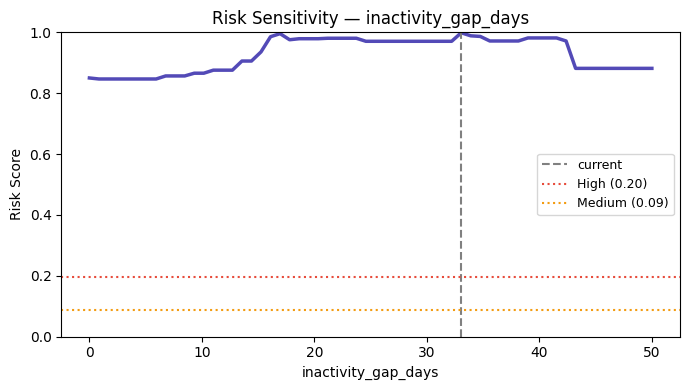

In [69]:
# Sensitivity curve
def sensitivity_curve(patient_id, feature):
    idx    = df[df['patient_id']==patient_id].index[0]
    values = np.linspace(df[feature].min(), df[feature].max(), 60)
    risk_r = []
    for v in values:
        X_tmp = X.iloc[idx].values.copy()
        X_tmp[FEATURE_COLS.index(feature)] = v
        risk_r.append(best_model.predict_proba(X_tmp.reshape(1,-1))[0][1])
    q40 = df['risk_score'].quantile(0.40)
    q70 = df['risk_score'].quantile(0.70)
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(values, risk_r, color='#534ab7', linewidth=2.5)
    ax.axvline(df.loc[idx,feature], color='gray', linestyle='--', label='current')
    ax.axhline(q70, color='#e74c3c', linestyle=':', label=f'High ({q70:.2f})')
    ax.axhline(q40, color='#f39c12', linestyle=':', label=f'Medium ({q40:.2f})')
    ax.set_xlabel(feature); ax.set_ylabel('Risk Score')
    ax.set_ylim(0,1); ax.set_title(f'Risk Sensitivity — {feature}')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

sensitivity_curve(worklist.iloc[0]['patient_id'], 'inactivity_gap_days')

## Step 8 — Save Outputs

In [ ]:
df.to_csv('patient_final.csv', index=False)
worklist.to_csv('clinician_worklist.csv', index=False)
nudge_queue.to_csv('nudge_queue.csv', index=False)
print(f"Saved: patient_final.csv ({len(df)} rows)")
print(f"Saved: clinician_worklist.csv ({len(worklist)} rows)")
print(f"Saved: nudge_queue.csv ({len(nudge_queue)} rows)")
print(f"\nBest model: {best_name}")
df[['patient_id','risk_score','risk_tier','segment','action','top_driver']].head(10)